In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.dates as dates
import math

import numpy as np
import datetime
from IPython.display import display
import pandas as pd

from garmindb import GarminConnectConfigManager
from garmindb.garmindb import GarminSummaryDb, DaysSummary, MonitoringDb, MonitoringHeartRate, Sleep, GarminDb
from garmindb.summarydb import DaysSummary, SummaryDb

from jupyter_funcs import format_number
from graphs import Graph

In [3]:
def minsFromTime(t):
    return float(t.hour * 3600 + t.minute * 60 + t.second) / 60.0

In [39]:
# start date
start_ts = datetime.datetime.combine(datetime.date(year=2025, month=6, day=5), datetime.datetime.min.time())
# end date (today)
end_ts = datetime.datetime.combine(datetime.date.today(), datetime.datetime.max.time())

gc_config = GarminConnectConfigManager()
db_params = gc_config.get_db_params()

garmin_db = GarminDb(db_params)
sum_db = SummaryDb(db_params, False)
data = DaysSummary.get_for_period(sum_db, start_ts, end_ts, DaysSummary)
sleep = Sleep.get_for_period(garmin_db, start_ts, end_ts)

time = [entry.day for entry in data]

In [40]:
stress_avg = [entry.stress_avg for entry in data]
bb_max = [entry.bb_max for entry in data]
bb_min = [entry.bb_min for entry in data]
rem_sleep_max = [minsFromTime(entry.rem_sleep_avg) for entry in data]
sleep_avg = [minsFromTime(entry.sleep_avg) / 60 for entry in data]
deep_sleep = [minsFromTime(sleep_event.deep_sleep) for sleep_event in sleep]
dm_df = pd.DataFrame([time, stress_avg, bb_max, bb_min, rem_sleep_max,deep_sleep, sleep_avg]).T
dm_df.columns = ["Date", "stress_avg", "bb_max", "bb_min", "rem_sleep_max", "deep_sleep", "sleep_avg"]
# remove the last record 'cause it's noisy sometimes
dm_df.drop(dm_df.tail(1).index,inplace=True) 
dm_df = dm_df[dm_df["sleep_avg"] > 0]
print(dm_df)



          Date stress_avg bb_max bb_min rem_sleep_max deep_sleep sleep_avg
0   2025-06-06         41     93      5          31.0      100.0  6.516667
1   2025-06-07         23     74      5          71.0       90.0      8.85
2   2025-06-08         26    100     20          53.0      117.0      8.45
3   2025-06-09         28     94     18          37.0       84.0  6.830833
4   2025-06-10         26     83     21          69.0       80.0      6.55
5   2025-06-11         33     98     11          69.0       72.0  6.916667
6   2025-06-12         27     75     11          38.0      106.0  7.133333
7   2025-06-13         30     93     21          68.0      108.0  7.577222
8   2025-06-14         33     89     18          73.0      124.0  7.578611
9   2025-06-15         18    100     16          68.0      101.0  8.225556
10  2025-06-16         27    100     28          62.0       98.0  9.533333


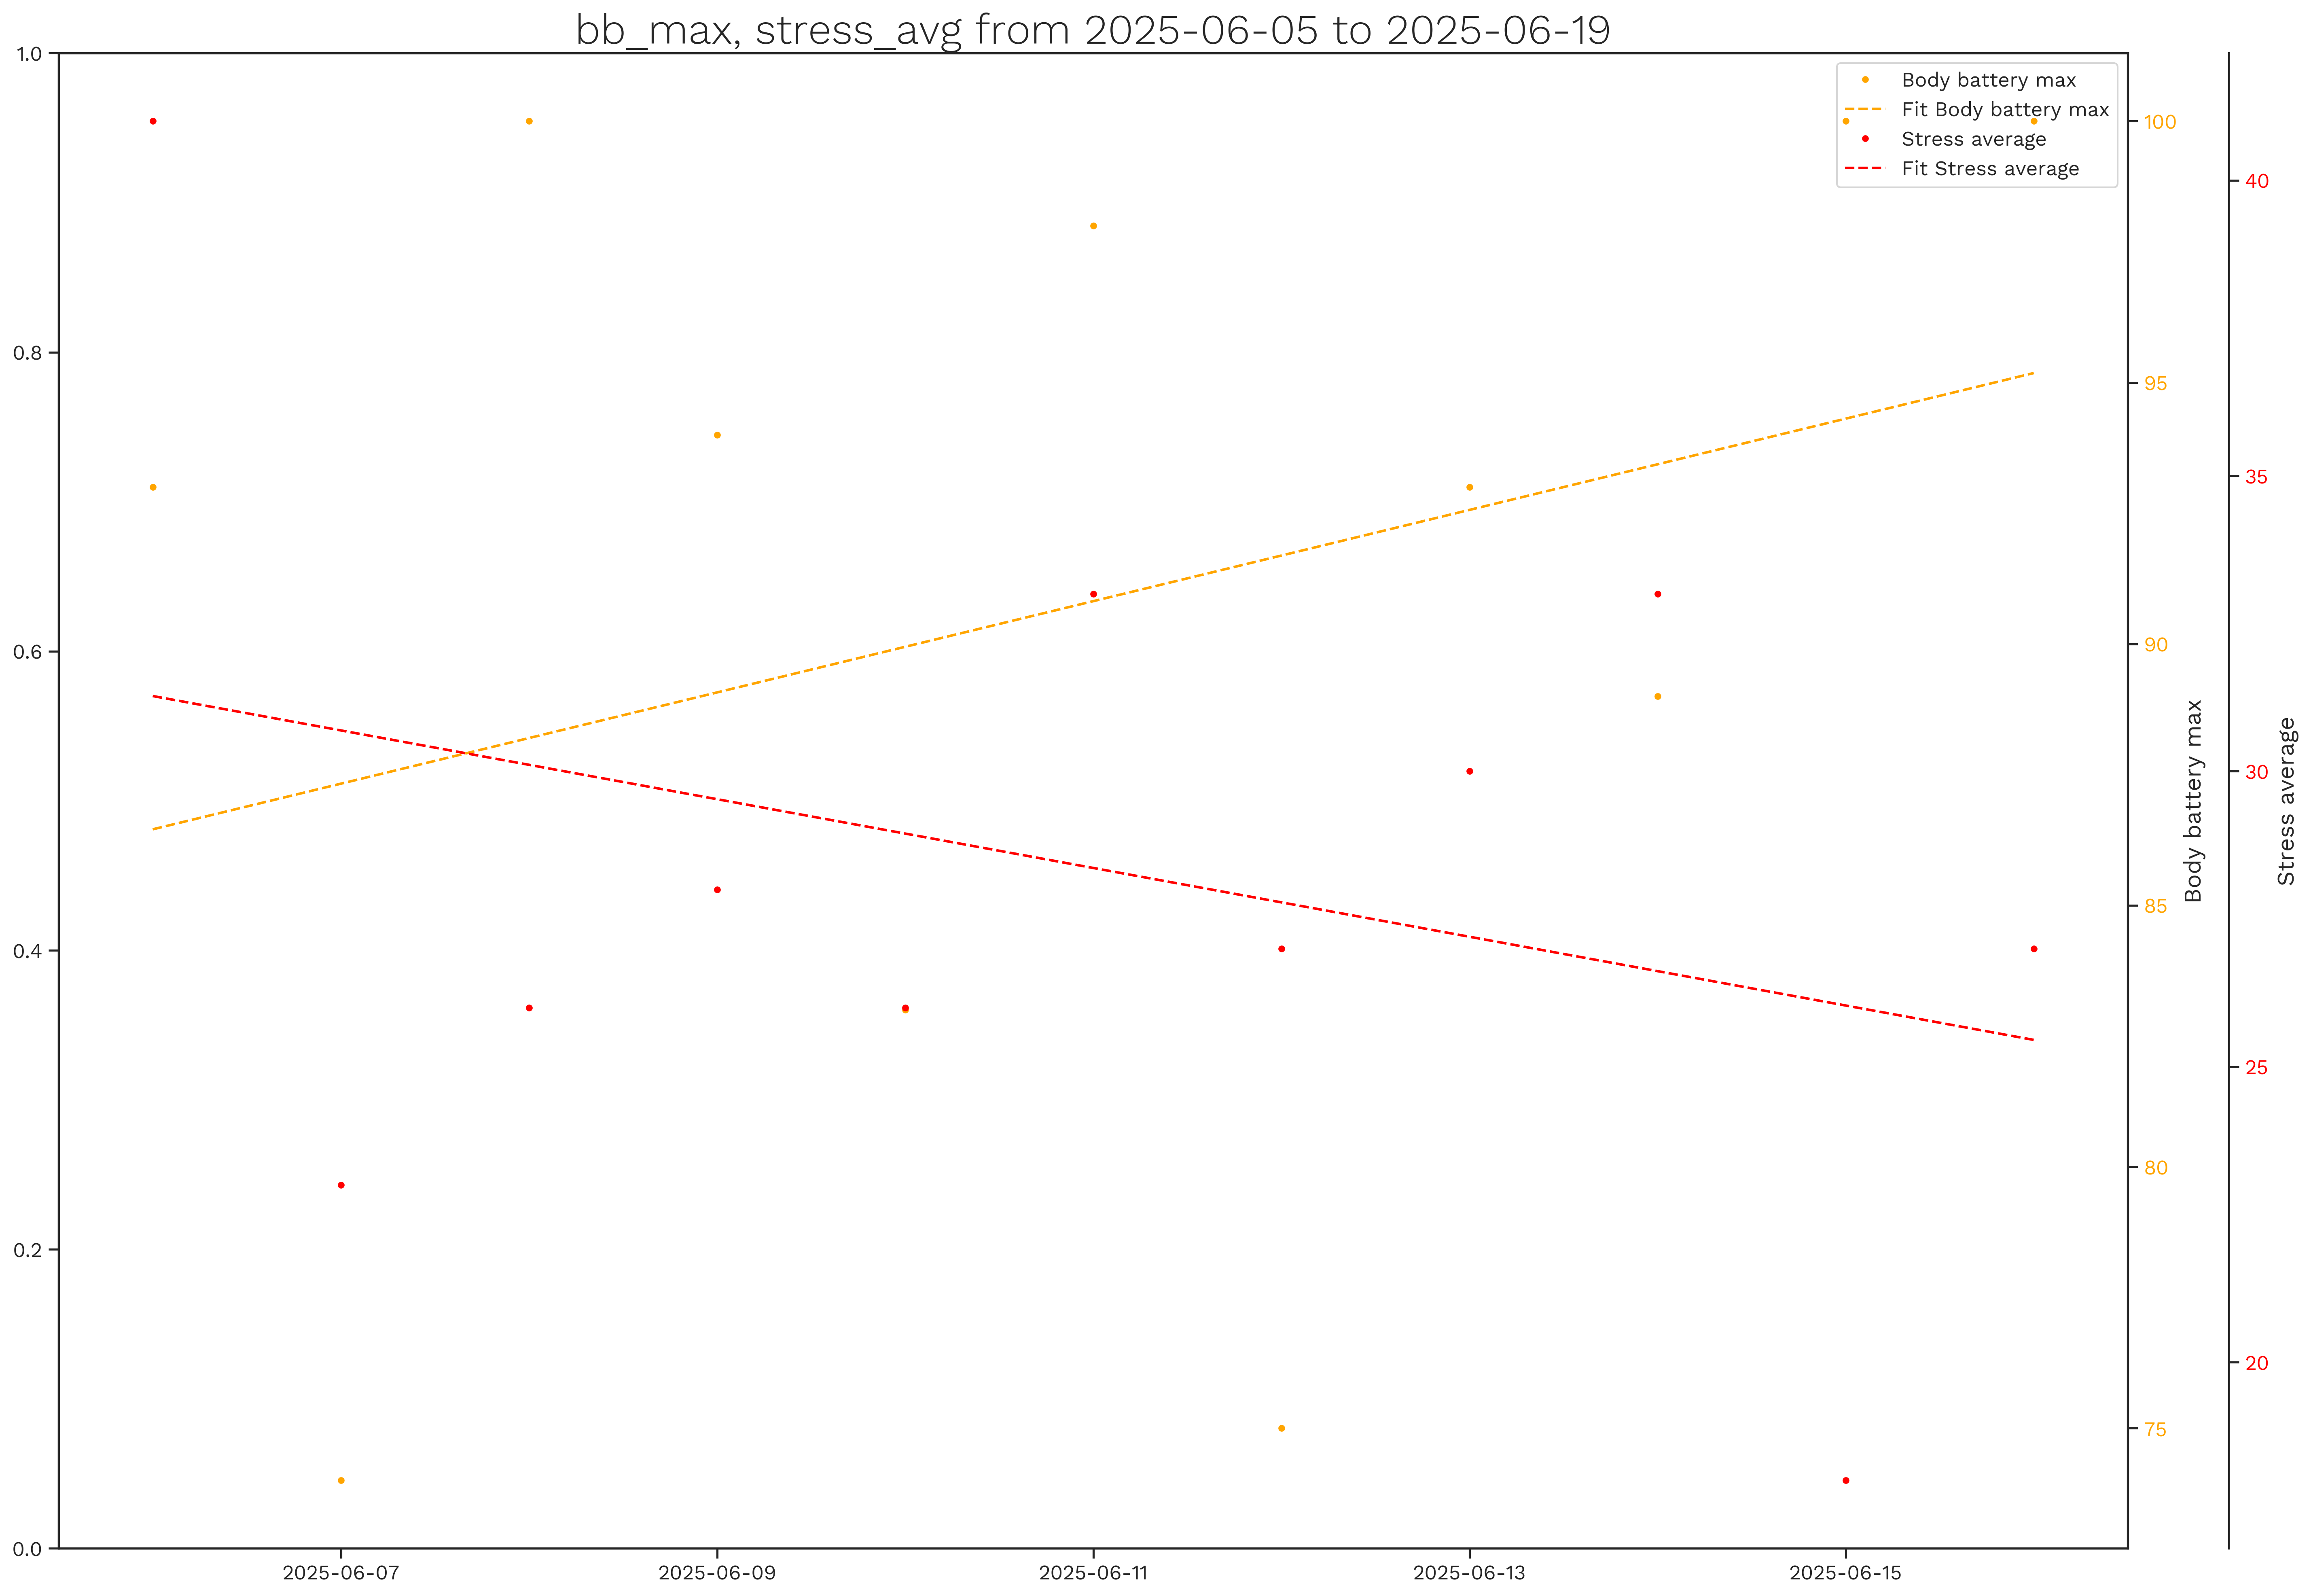

,,min,max
0,Fit Body battery max,86,95
1,Fit Stress average,25,31


In [67]:
columns = { "stress_avg" : 
                   {
                       "label": "Stress average",
                       "trend_marker": "--",
                       "color": "red"

                   }, 
            "bb_max": 
                   {
                       "label": "Body battery max",
                       "trend_marker": "--",
                       "color": "orange"
                   },
           
            "sleep_avg": 
                   {
                       "label": "Sleep time (hrs)",
                       "trend_marker": "-.",
                       "color": "blue"
                  },
            "rem_sleep_max": 
                   {
                       "label": "Rem Sleep time (mins)",
                       "trend_marker": "-",
                       "color": "purple"
                   },
           
            "deep_sleep": 
                   {
                       "label": "Deep sleep (mins)",
                       "trend_marker": "-",
                       "color": "green"
                   }
          }

# these are the data columns to plot
show_cols = {"stress_avg", "bb_max"}

fig, host = plt.subplots(figsize=(22,16))

plots = []
fit_summary = []
step = 0

for col in show_cols:
    label=columns[col]["label"]
   
    ax2 = host.twinx()
    ax2.set_ylabel(label)
    ax2.tick_params(axis='y', labelcolor=columns[col]["color"])

    # data
    plot, = ax2.plot(dm_df.Date, dm_df[col], 'o', ms=3.0, color=columns[col]["color"], label=label)
    plots.append(plot)
    
    # trend
    fitlabel = 'Fit {}'.format(label)
    x_dates = dates.date2num(dm_df.Date)
    trend = np.polyfit(x_dates, dm_df[col].astype(float) , 1)
    fit = np.poly1d(trend)
    x_fit = np.linspace(x_dates.min(), x_dates.max())
    fit, = ax2.plot(dates.num2date(x_fit), fit(x_fit), linestyle=columns[col]["trend_marker"], color=columns[col]["color"],label=fitlabel)
    plots.append(fit)
    
    ax2.spines['right'].set_position(('outward', step))
    
    step = step + 60

    fit_data = fit.get_ydata()
    
    fit_summary.append({"": fitlabel, "min": math.floor(fit_data.min()), "max":math.floor(fit_data.max())})
    
host.legend(handles=plots, loc='best')

col_label = ""
for col in show_cols:
    if len(col_label):
        col_label += ", "
    col_label += f"{col}"

title = f"{col_label} from {start_ts.date()} to {end_ts.date()}"

plt.title(label=title, fontsize=25)

plt.show()
pd.DataFrame(fit_summary)

/tmp/ipykernel_2852709/2381074332.py:54: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  pivot = pivot.fillna(0)  # ensure no NaNs


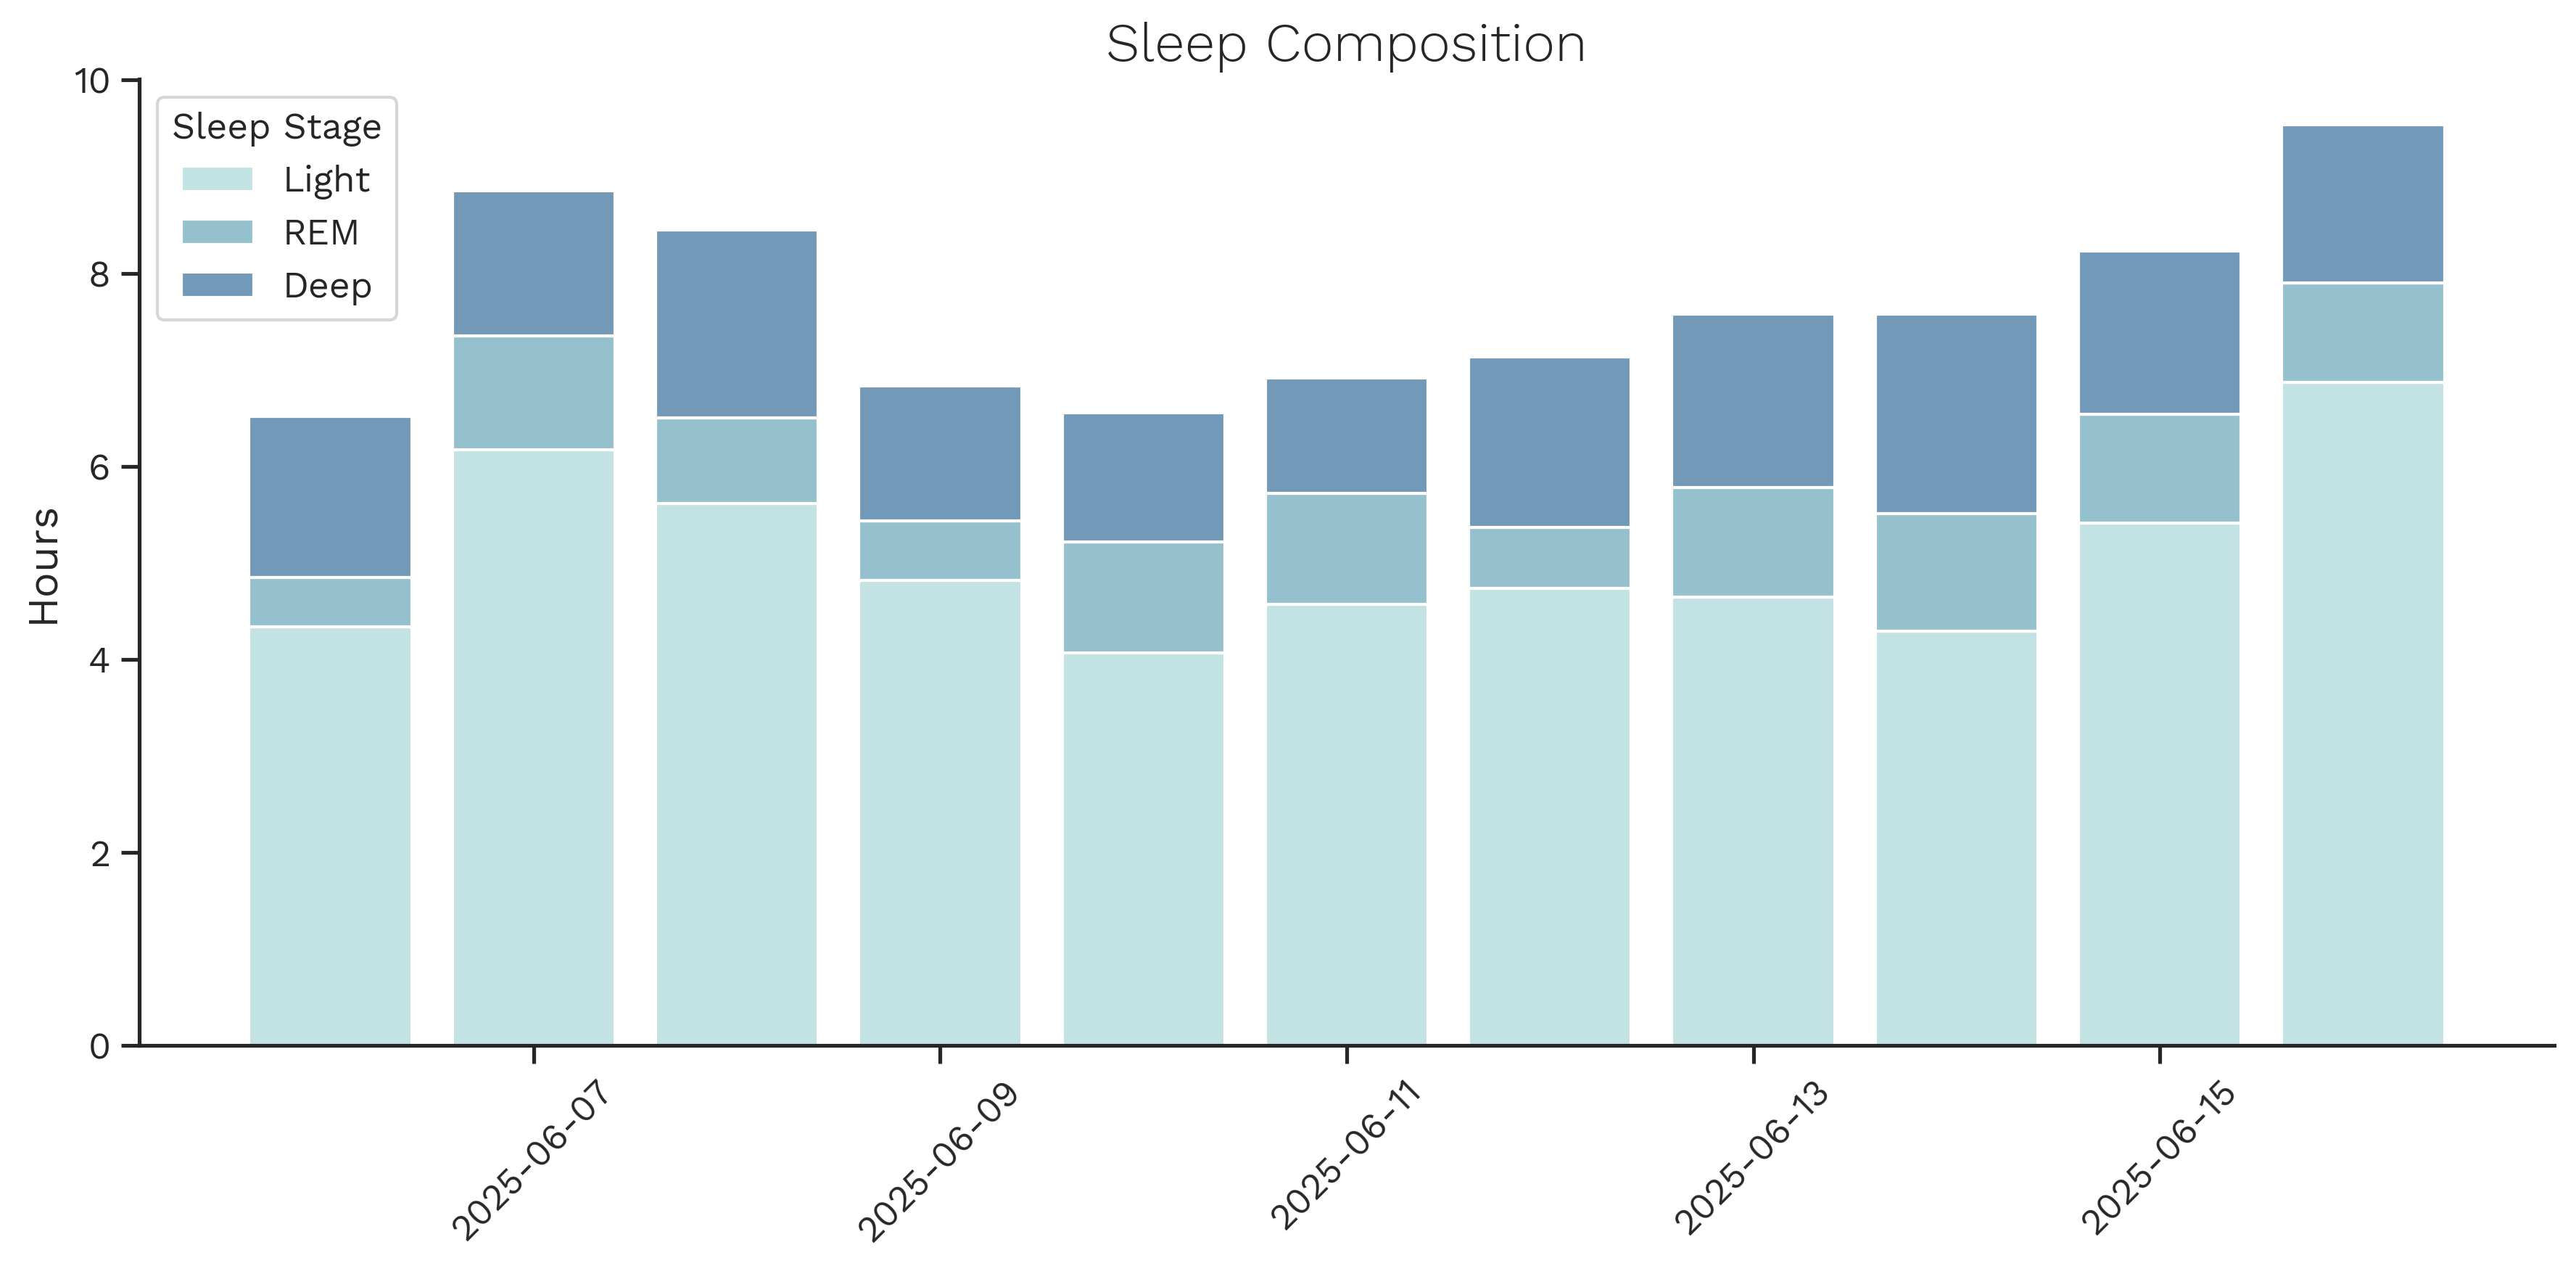

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

def set_style():
    sns.set_context("poster", font_scale=1.5)
    rc = {
        "font.family": "sans-serif",
        "font.sans-serif": "Work Sans",
        # "axes.spines.top": False,
        # "axes.spines.right": False,
        "axes.labelsize": 14,
        "axes.titlesize": 16,
        "axes.titleweight": 300,
        "axes.labelweight": 400,
        "legend.fontsize": 12,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "figure.dpi": 300,
        "savefig.bbox": "tight",
    }
    palette = sns.color_palette("ch:start=.2,rot=-.3")
    sns.set_theme(palette=palette, rc=rc, style="ticks")
    return palette


# --- Prepare Data ---
df = dm_df.copy()
df["deep_sleep"] = df["deep_sleep"] / 60
df["rem_sleep_max"] = df["rem_sleep_max"] / 60

df["light_sleep"] = df["sleep_avg"] - df["deep_sleep"] - df["rem_sleep_max"]
df["light_sleep"] = df["light_sleep"].clip(lower=0)

# Melt into long format for stacking
df_long = df[["Date", "deep_sleep", "rem_sleep_max", "light_sleep"]].melt(
    id_vars="Date",
    var_name="Sleep Stage",
    value_name="Hours"
)

# Optional: Rename for prettier legend
df_long["Sleep Stage"] = df_long["Sleep Stage"].map({
    "deep_sleep": "Deep",
    "rem_sleep_max": "REM",
    "light_sleep": "Light"
})

# --- Plot ---
palette = set_style()
plt.figure(figsize=(12, 6))

# We need to pivot the data to use Matplotlib for stacking
pivot = df_long.pivot(index="Date", columns="Sleep Stage", values="Hours")
pivot = pivot.fillna(0)  # ensure no NaNs
pivot.index.strftime('%m-%d')  # "06-17"


# Order the stack from bottom to top
stack_order = ["Light", "REM", "Deep"]
colors = {
    "Light": palette[0],
    "REM": palette[1],
    "Deep": palette[2]
}

# Plot stacked bars manually
bottom = None
for stage in stack_order:
    plt.bar(pivot.index, pivot[stage], bottom=bottom, label=stage, color=colors[stage])
    if bottom is None:
        bottom = pivot[stage]
    else:
        bottom += pivot[stage]

# --- Styling ---
plt.title("Sleep Composition", fontsize=18)
plt.ylabel("Hours")
plt.xticks(rotation=45)
plt.legend(title="Sleep Stage")
sns.despine()
plt.tight_layout()
plt.show()
